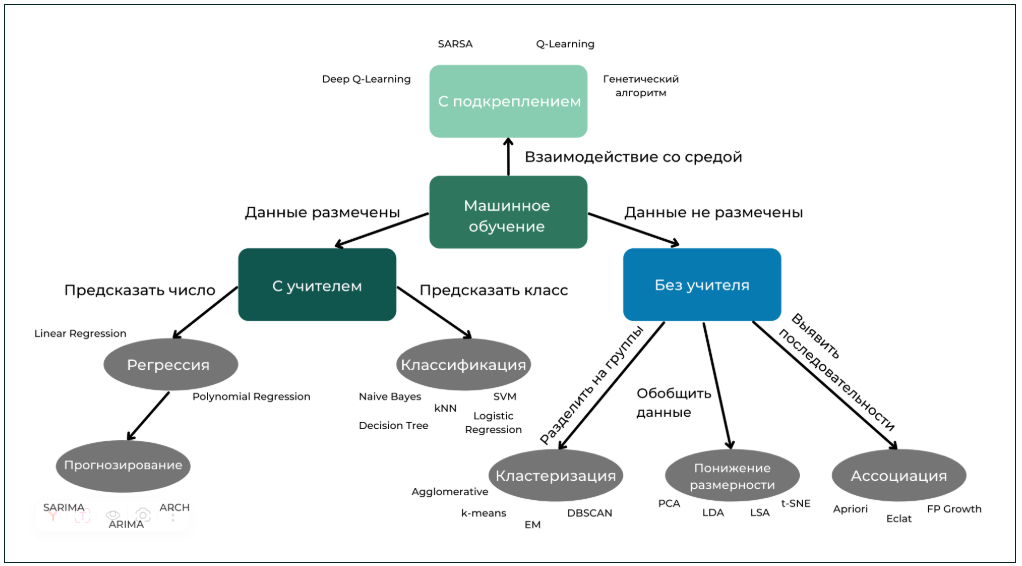

✅ Изображение загружено!


: 

In [ ]:
import os
from IPython.display import Image, display

# 1. Либо используйте полный путь напрямую
full_path = r'C:\Users\Admin\Desktop\Обучение skillfactoury\Все виды ML.png'

if os.path.exists(full_path):
    display(Image(filename=full_path))
    print("✅ Изображение загружено!")
else:
    print(f"❌ Файл не найден: {full_path}")
    # Проверим, есть ли файл с другим именем
    folder = r'C:\Users\Admin\Desktop\Обучение skillfactoury'
    if os.path.exists(folder):
        files = os.listdir(folder)
        print(f"Файлы в папке '{folder}':")
        for f in files:
            print(f"  - {f}")

# Создание анализируемой выборки данных для разделения на тестовые и тренеровочныемодели

In [3]:
# УНИВЕРСАЛЬНЫЙ КОД ДЛЯ РАЗДЕЛЕНИЯ ЛЮБЫХ ДАННЫХ
from sklearn.model_selection import train_test_split
import numpy as np
def split_data_any(X, y, test_size=0.2, random_state=42):
    """
    Универсальная функция для разделения любых данных
    
    Параметры:
    -----------
    X : array-like, shape (n_samples, n_features)
        Признаки (матрица наблюдений)
    y : array-like, shape (n_samples,)
        Целевая переменная (вектор ответов)
    test_size : float, default=0.2
        Доля тестовой выборки (от 0.0 до 1.0)
    random_state : int, default=42
        Случайное зерно для воспроизводимости
    
    Возвращает:
    -----------
    X_train, X_test, y_train, y_test
    """
    
    # Проверяем, что X и y имеют одинаковое количество строк
    assert len(X) == len(y), f"Размеры X ({len(X)}) и y ({len(y)}) не совпадают!"
    
    # Разделяем данные
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if hasattr(y, 'nunique') and y.nunique() > 1 else None
    )
    
    # Выводим информацию
    print(f"✅ Данные успешно разделены!")
    print(f"   Всего наблюдений: {len(X)}")
    print(f"   Размер train выборки: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Размер test выборки: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    if hasattr(X, 'shape'):
        print(f"   Признаков (features): {X.shape[1] if len(X.shape) > 1 else 1}")
    
    # Для классификации: показываем распределение классов
    if hasattr(y, '__len__') and len(set(y)) < 20:  # Если это классификация
        print(f"\n📊 Распределение классов в обучающей выборке:")
        unique_train, counts_train = np.unique(y_train, return_counts=True)
        unique_test, counts_test = np.unique(y_test, return_counts=True)
        
        for cls, cnt_train, cnt_test in zip(unique_train, counts_train, counts_test):
            print(f"   Класс {cls}: train={cnt_train}, test={cnt_test}")
    
    return X_train, X_test, y_train, y_test

from sklearn import metrics #метрики
def print_metrics_simple(y_train, y_train_predict, y_test, y_test_predict):
    """
    Простая версия с исправлением бага (было 'Train MAPE' для теста).
    """
    print('=' * 50)
    print('TRAIN METRICS:')
    print('=' * 50)
    print('R^2:  {:.4f}'.format(metrics.r2_score(y_train, y_train_predict)))
    print('MAE:  {:.4f}'.format(metrics.mean_absolute_error(y_train, y_train_predict)))
    print('MSE:  {:.4f}'.format(metrics.mean_squared_error(y_train, y_train_predict)))
    print('RMSE: {:.4f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_train_predict))))
    print('MAPE: {:.2f}%'.format(metrics.mean_absolute_percentage_error(y_train, y_train_predict) * 100))
    
    print('\n' + '=' * 50)
    print('TEST METRICS:')
    print('=' * 50)
    print('R^2:  {:.4f}'.format(metrics.r2_score(y_test, y_test_predict)))
    print('MAE:  {:.4f}'.format(metrics.mean_absolute_error(y_test, y_test_predict)))
    print('MSE:  {:.4f}'.format(metrics.mean_squared_error(y_test, y_test_predict)))
    print('RMSE: {:.4f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_test_predict))))
    print('MAPE: {:.2f}%'.format(metrics.mean_absolute_percentage_error(y_test, y_test_predict) * 100))
    
    # Добавляем сравнение
    print('\n' + '=' * 50)
    print('COMPARISON:')
    print('=' * 50)
    r2_diff = metrics.r2_score(y_test, y_test_predict) - metrics.r2_score(y_train, y_train_predict)
    print('R² difference (Test - Train): {:.4f}'.format(r2_diff))
    
    if r2_diff < -0.05:
        print('⚠️  Warning: Possible overfitting (Test R² significantly lower)')
    elif r2_diff > 0.05:
        print('ℹ️  Note: Test R² higher than Train R² (unusual)')
    else:
        print('✅ Good: Minimal difference between Train and Test R²')

# Классификация Нейросетей

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn import metrics #метрики

## Регрессия

### 1. Линейная регрессия(Liner regression)

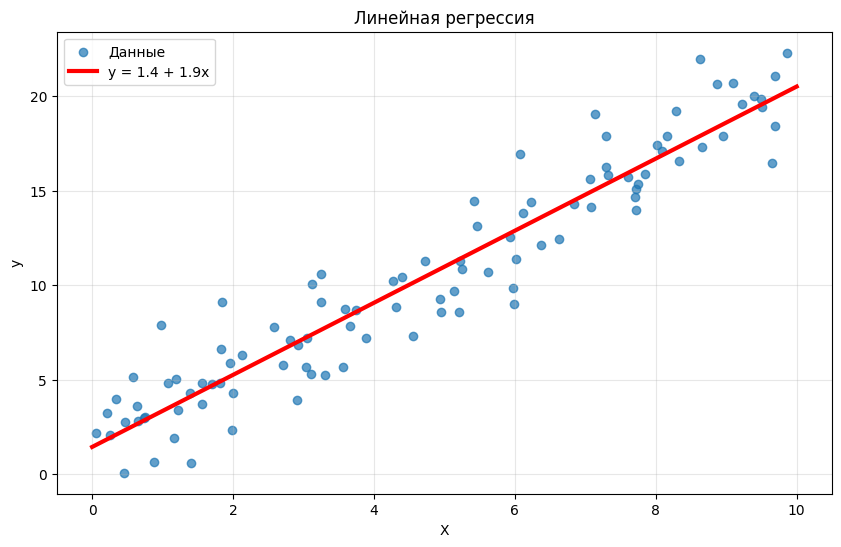

In [5]:
from sklearn.linear_model import LinearRegression

# Создаем данные
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# Модель
model = LinearRegression()
model.fit(X, y)

# Предсказания
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred = model.predict(X_line)

# График
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Данные')
plt.plot(X_line, y_pred, 'r-', linewidth=3, 
         label=f'y = {model.intercept_[0]:.1f} + {model.coef_[0][0]:.1f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Линейная регрессия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Полиномиальная регрессия(polynomial regression)

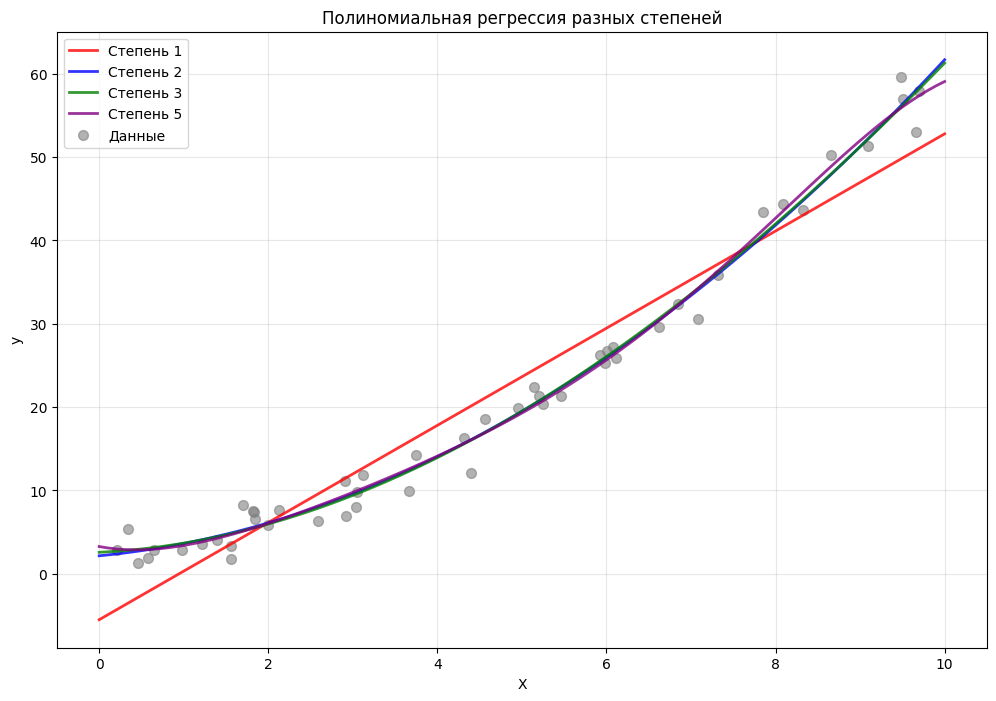

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Нелинейные данные
np.random.seed(42)
X = np.random.rand(50, 1) * 10
y = 0.5 * X**2 + X + 2 + np.random.randn(50, 1) * 2

degrees = [1, 2, 3, 5]
colors = ['red', 'blue', 'green', 'purple']

plt.figure(figsize=(12, 8))

for degree, color in zip(degrees, colors):
    # Создаем полиномиальную модель
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    # Предсказания
    X_line = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred = model.predict(X_line)
    
    plt.plot(X_line, y_pred, color=color, linewidth=2, 
             label=f'Степень {degree}', alpha=0.8)

plt.scatter(X, y, alpha=0.6, color='gray', s=50, label='Данные')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Полиномиальная регрессия разных степеней')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Прогназирование - временные ряды

### 1. ARIMA модель 

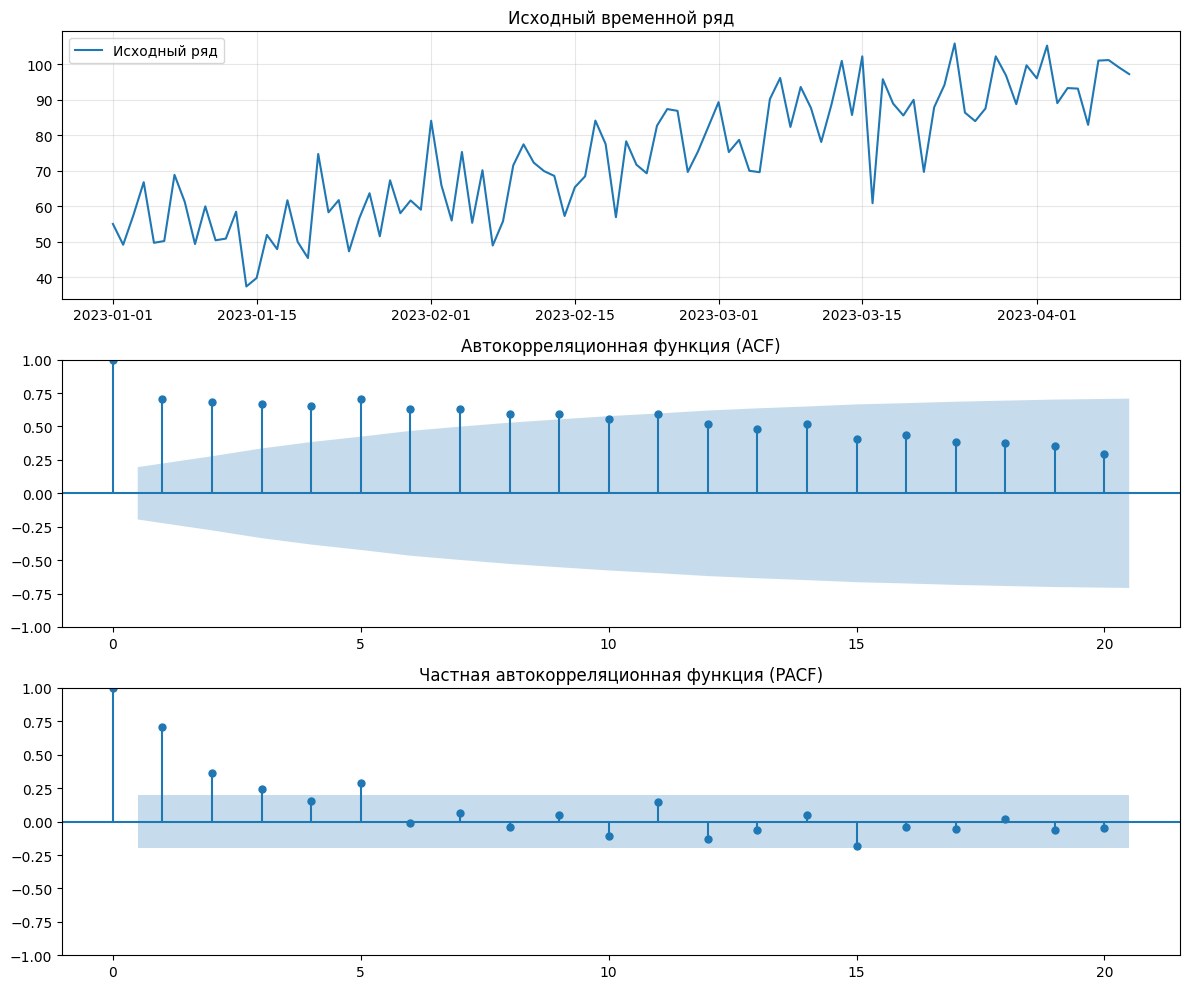

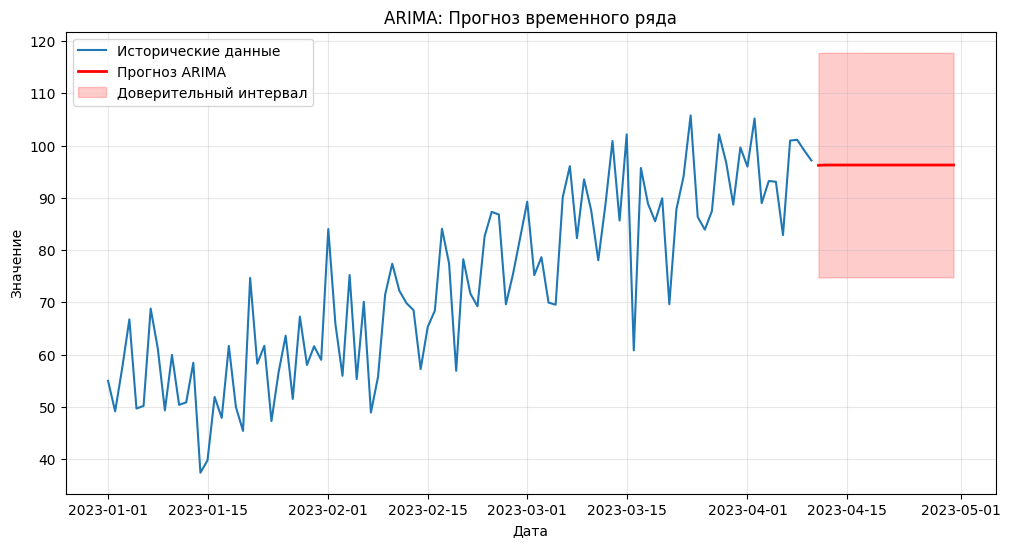

In [7]:
# ARIMA МОДЕЛЬ ДЛЯ ВРЕМЕННОГО РЯДА
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Создаем временной ряд
np.random.seed(42)
n = 100
time = pd.date_range(start='2023-01-01', periods=n, freq='D')
data = 50 + 0.5 * np.arange(n) + np.random.randn(n) * 10
series = pd.Series(data, index=time)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. Исходный ряд
axes[0].plot(series, label='Исходный ряд')
axes[0].set_title('Исходный временной ряд')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. ACF и PACF
plot_acf(series, lags=20, ax=axes[1])
axes[1].set_title('Автокорреляционная функция (ACF)')

plot_pacf(series, lags=20, ax=axes[2])
axes[2].set_title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

# ARIMA модель
model = ARIMA(series, order=(1, 1, 1))  # (p,d,q)
results = model.fit()

# Прогноз
forecast_steps = 20
forecast = results.forecast(steps=forecast_steps)

# График прогноза
plt.figure(figsize=(12, 6))
plt.plot(series, label='Исторические данные')
plt.plot(forecast.index, forecast, label='Прогноз ARIMA', color='red', linewidth=2)
plt.fill_between(forecast.index, 
                 forecast - 1.96*results.resid.std(), 
                 forecast + 1.96*results.resid.std(), 
                 color='red', alpha=0.2, label='Доверительный интервал')
plt.title('ARIMA: Прогноз временного ряда')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. SARIMA модель

C:\Users\Admin\AppData\Local\Temp\ipykernel_8224\2064922429.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='2020-01-01', periods=n, freq='M')
C:\Users\Admin\AppData\Local\Temp\ipykernel_8224\2064922429.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=series.index[-1], periods=forecast_steps+1, freq='M')[1:]


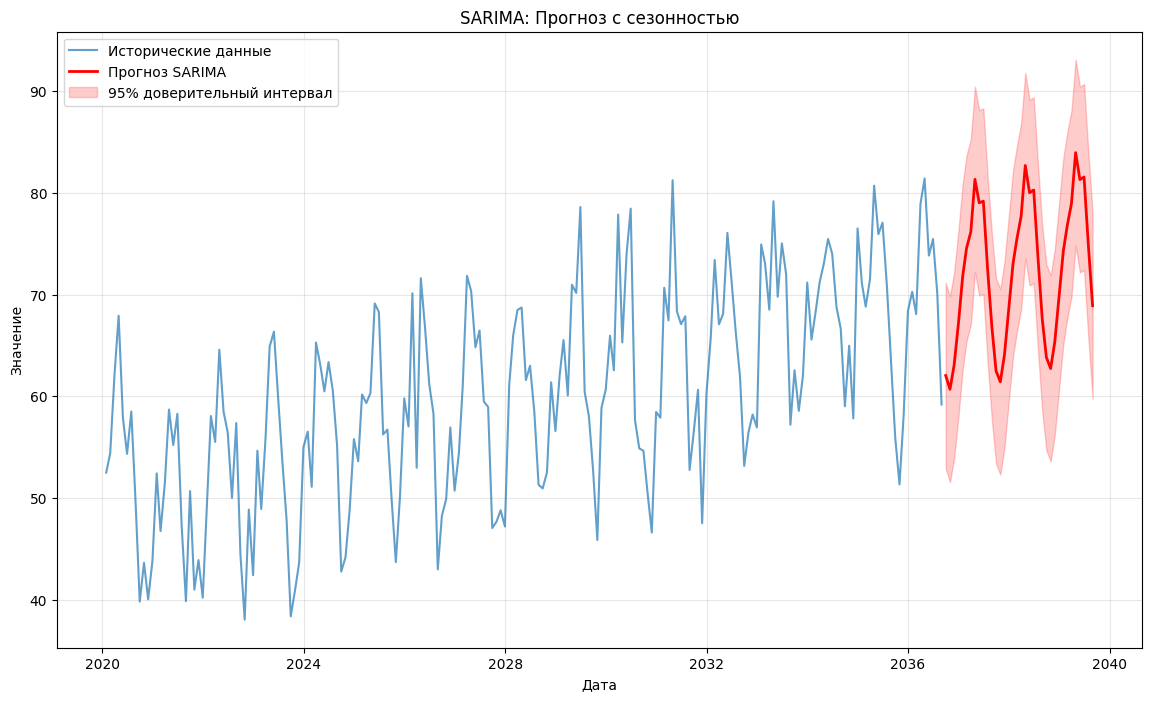

In [8]:
# SARIMA МОДЕЛЬ С СЕЗОННОСТЬЮ
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Создаем ряд с сезонностью
np.random.seed(42)
n = 200
time = pd.date_range(start='2020-01-01', periods=n, freq='M')
trend = 0.1 * np.arange(n)
seasonality = 10 * np.sin(2 * np.pi * np.arange(n) / 12)  # Годовая сезонность
noise = np.random.randn(n) * 5
data = 50 + trend + seasonality + noise
series = pd.Series(data, index=time)

# SARIMA модель
model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# Прогноз
forecast_steps = 36
forecast = results.forecast(steps=forecast_steps)
conf_int = results.get_forecast(steps=forecast_steps).conf_int()

# График
plt.figure(figsize=(14, 8))
plt.plot(series, label='Исторические данные', alpha=0.7)

# Прогноз
forecast_index = pd.date_range(start=series.index[-1], periods=forecast_steps+1, freq='M')[1:]
plt.plot(forecast_index, forecast, label='Прогноз SARIMA', color='red', linewidth=2)
plt.fill_between(forecast_index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% доверительный интервал')

# Компоненты
if hasattr(results, 'plot_components'):
    results.plot_components()
    plt.suptitle('SARIMA: Компоненты ряда')

plt.title('SARIMA: Прогноз с сезонностью')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

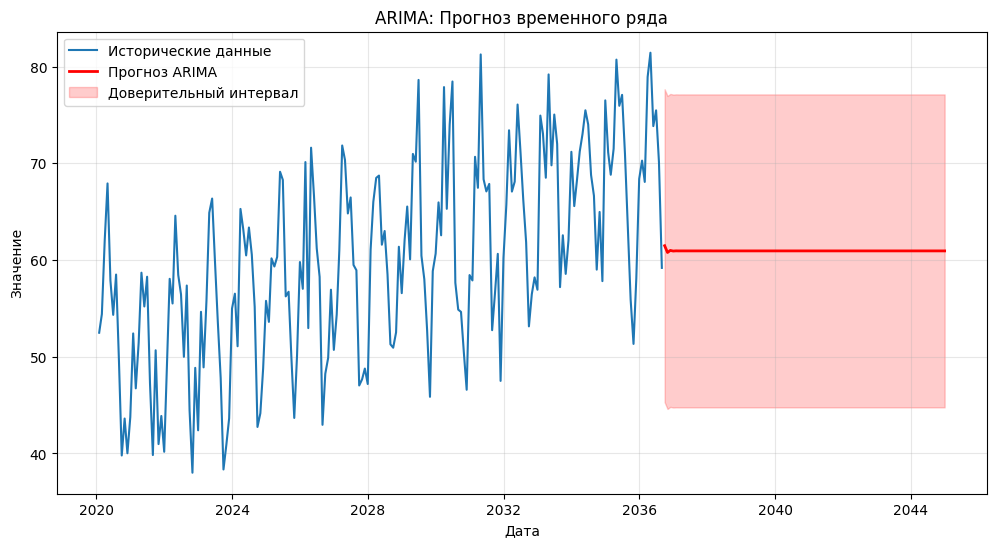

In [9]:

model = ARIMA(series, order=(1, 1, 1))  # (p,d,q)
results = model.fit()

# Прогноз
forecast_steps = 100
forecast = results.forecast(steps=forecast_steps)

# График прогноза
plt.figure(figsize=(12, 6))
plt.plot(series, label='Исторические данные')
plt.plot(forecast.index, forecast, label='Прогноз ARIMA', color='red', linewidth=2)
plt.fill_between(forecast.index, 
                 forecast - 1.96*results.resid.std(), 
                 forecast + 1.96*results.resid.std(), 
                 color='red', alpha=0.2, label='Доверительный интервал')
plt.title('ARIMA: Прогноз временного ряда')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3. ARCH/GARCH

Обучение GARCH модели...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1165.4066349772088
            Iterations: 9
            Function evaluations: 55
            Gradient evaluations: 9
Готово!


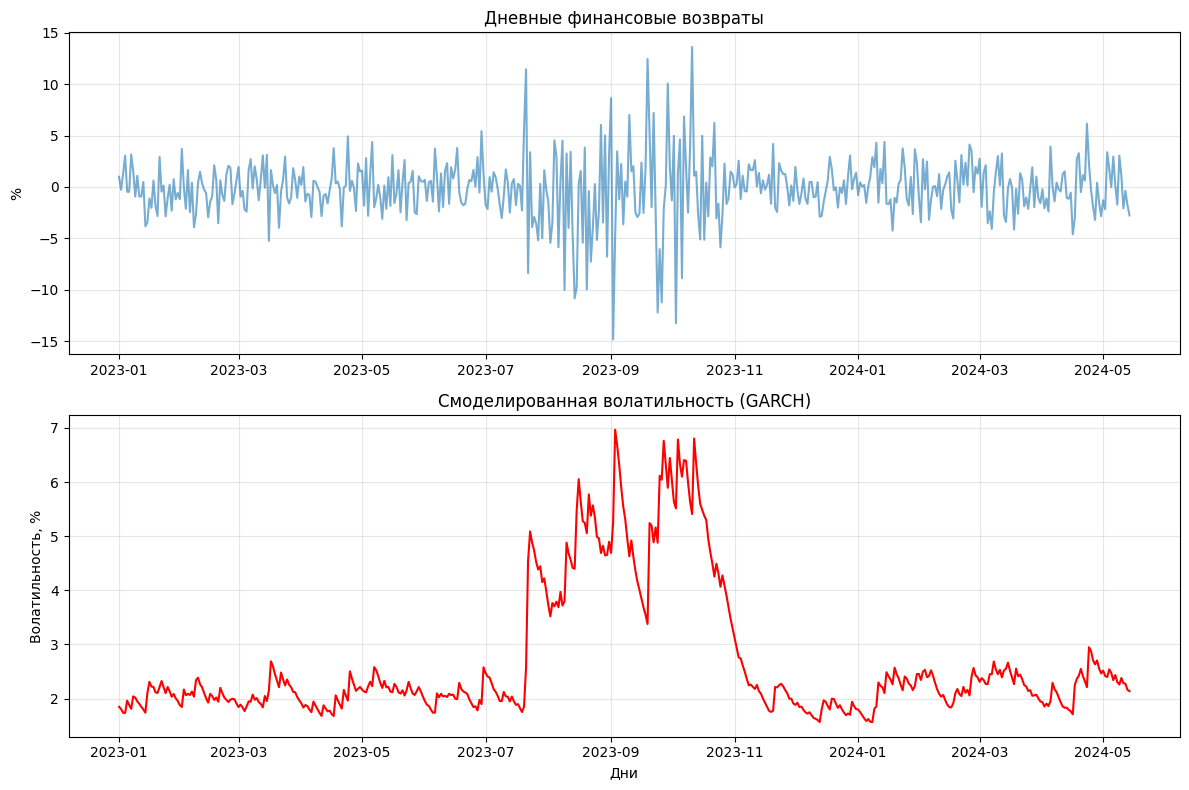


Параметры модели:
α (ARCH): 0.1120
β (GARCH): 0.8617
α+β: 0.9737


In [10]:
# УПРОЩЕННЫЙ ARCH/GARCH ПРИМЕР
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Создаем простой временной ряд
np.random.seed(42)
n = 500
returns = np.random.randn(n) * 0.02  # Более реалистичная волатильность

# Простой ARCH эффект
for i in range(200, 300):
    returns[i] = np.random.randn() * 0.06  # Кластер высокой волатильности

# Создаем Series
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')
returns_series = pd.Series(returns * 100, index=dates)

# Простая GARCH модель
print("Обучение GARCH модели...")
model = arch_model(returns_series, vol='Garch', p=1, q=1)
results = model.fit(update_freq=0)  # Не показывать итерации
print("Готово!")

# Простая визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Возвраты
ax1.plot(returns_series, alpha=0.6)
ax1.set_title('Дневные финансовые возвраты')
ax1.set_ylabel('%')
ax1.grid(True, alpha=0.3)

# Волатильность
ax2.plot(results.conditional_volatility, color='red')
ax2.set_title('Смоделированная волатильность (GARCH)')
ax2.set_xlabel('Дни')
ax2.set_ylabel('Волатильность, %')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Простые выводы
params = results.params
print(f"\nПараметры модели:")
print(f"α (ARCH): {params['alpha[1]']:.4f}")
print(f"β (GARCH): {params['beta[1]']:.4f}")
print(f"α+β: {params['alpha[1]'] + params['beta[1]']:.4f}")

## Классификация

### 1. Логистическая регрессия

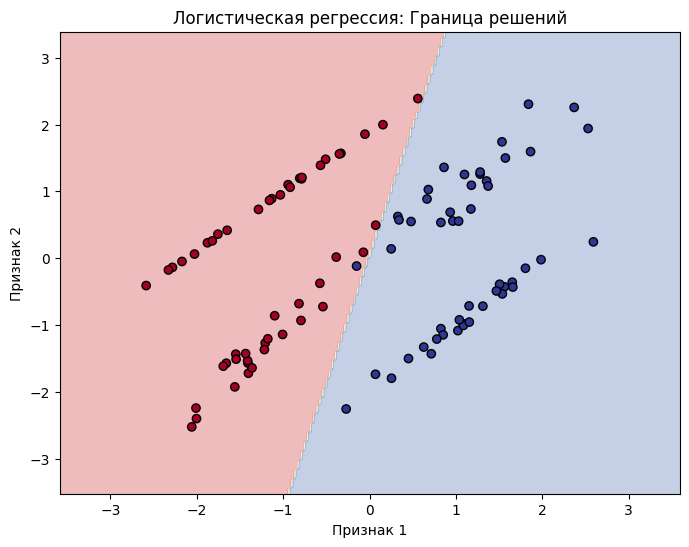

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Данные
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, 
                          n_informative=2, n_redundant=0, random_state=42)

# Модель
model = LogisticRegression()
model.fit(X, y)

# Граница решений
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# График
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k')
plt.title('Логистическая регрессия: Граница решений')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()


### 2. Метод опорных векторов (SVM)

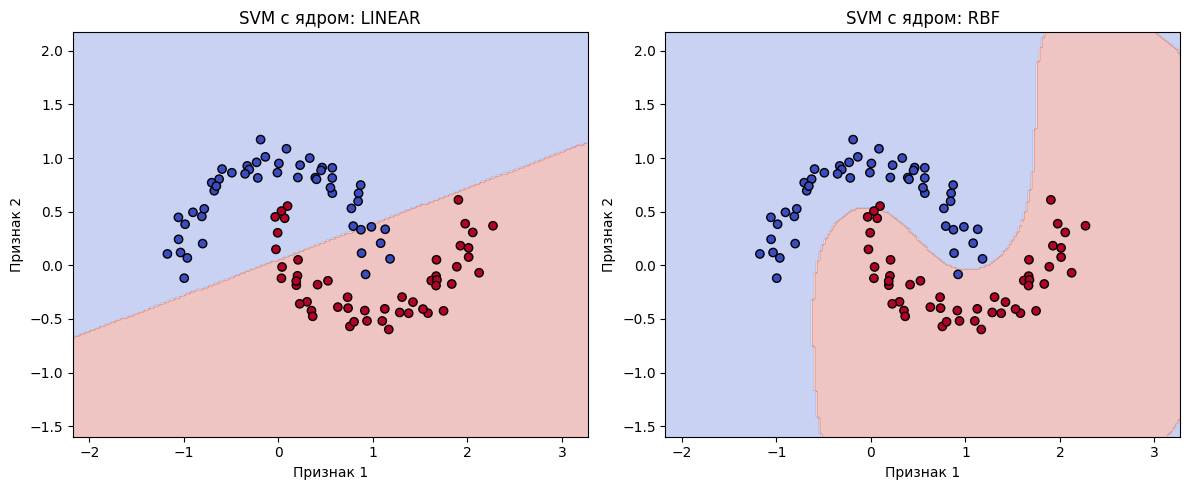

In [12]:

# SVM С РАЗНЫМИ ЯДРАМИ
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Создаем нелинейные данные
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, kernel in zip(axes, ['linear', 'rbf']):
    model = SVC(kernel=kernel, C=1.0)
    model.fit(X, y)
    
    # Сетка для границы
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'SVM с ядром: {kernel.upper()}')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

plt.tight_layout()
plt.show()





### 3. Дерево решений

Размер X: (100, 2)
Классы: [0 1]
Баланс классов: [50 50]


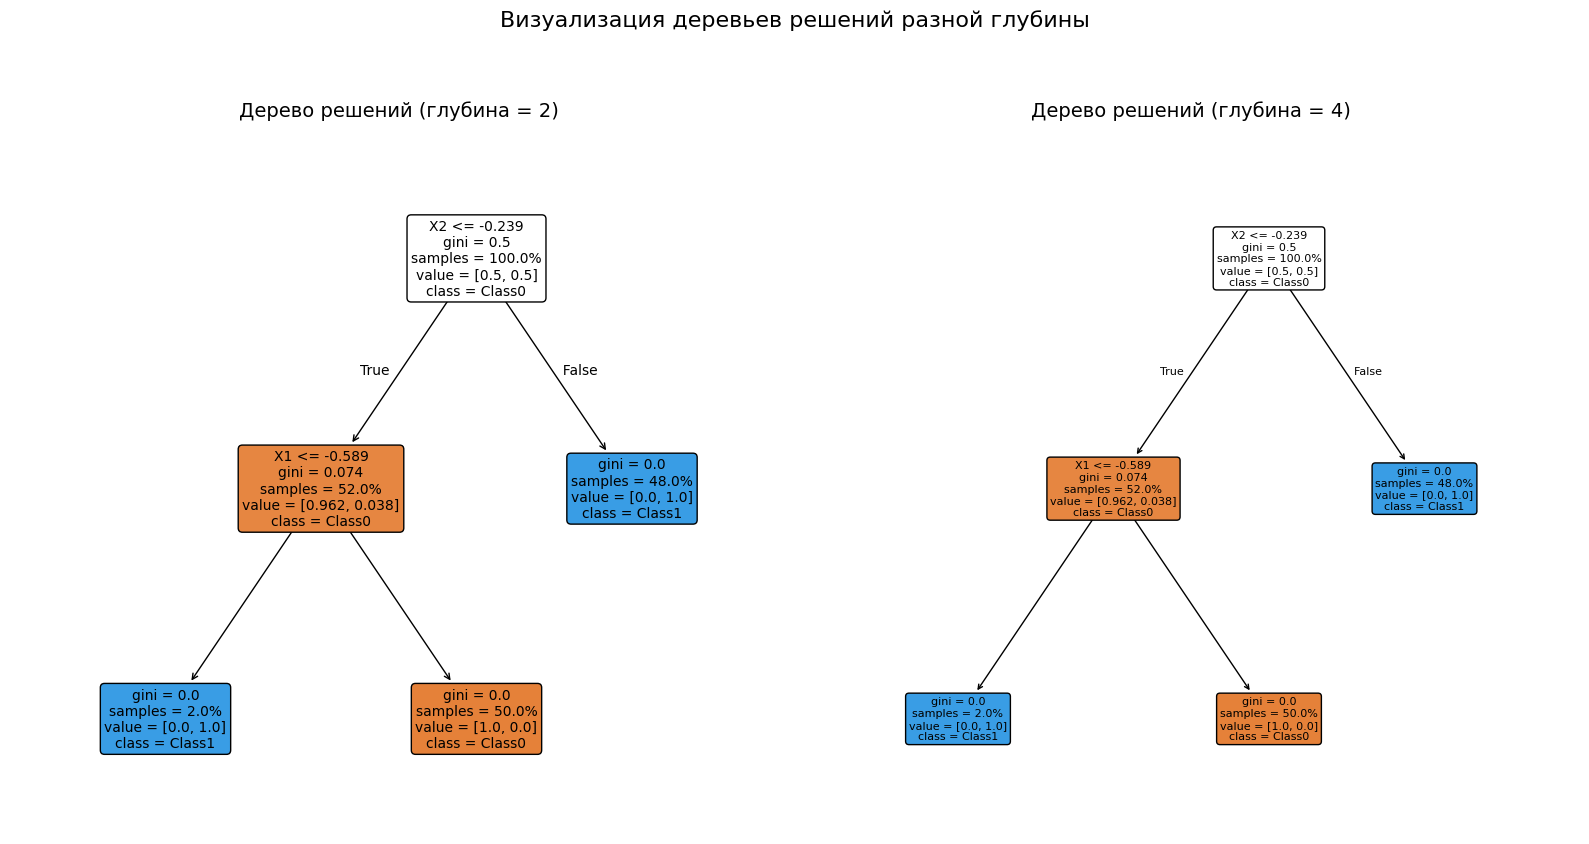

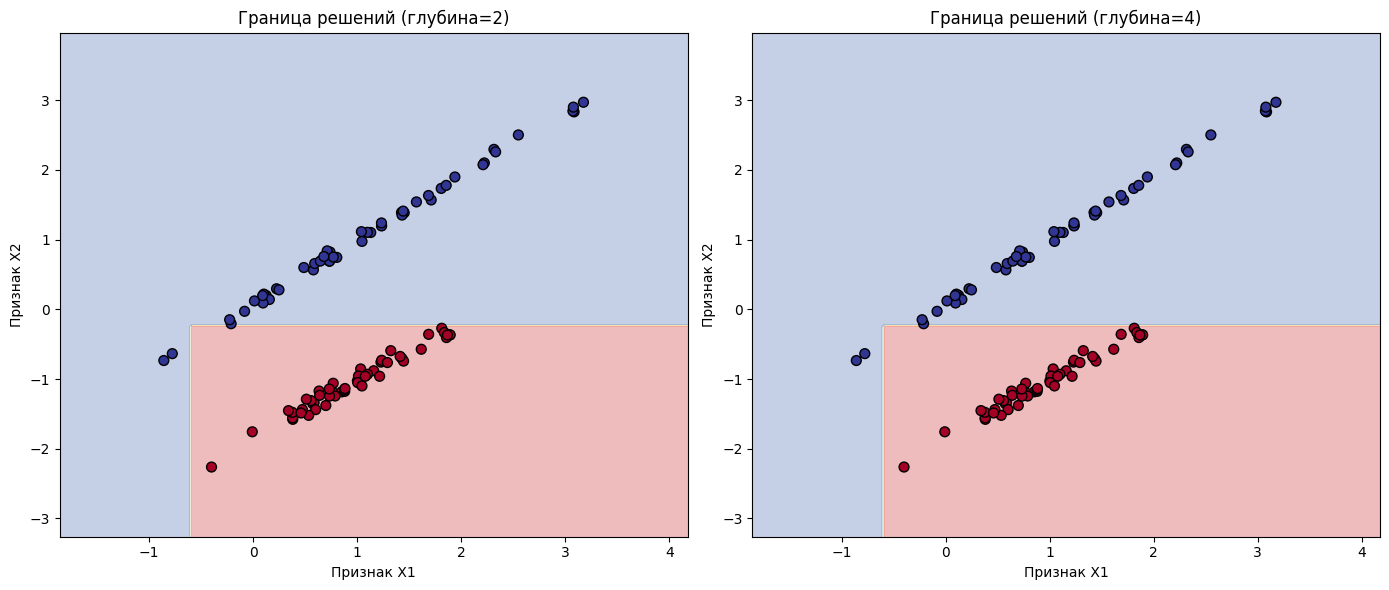


📊 СРАВНЕНИЕ МОДЕЛЕЙ:
----------------------------------------
Глубина 2:
  Точность на обучении: 1.000
  Точность на тесте:    1.000
  Разница:              0.000
  Количество узлов:     5

Глубина 4:
  Точность на обучении: 1.000
  Точность на тесте:    1.000
  Разница:              0.000
  Количество узлов:     5

Глубина 6:
  Точность на обучении: 1.000
  Точность на тесте:    1.000
  Разница:              0.000
  Количество узлов:     5

Глубина 10:
  Точность на обучении: 1.000
  Точность на тесте:    1.000
  Разница:              0.000
  Количество узлов:     5



In [13]:

# ДЕРЕВО РЕШЕНИЙ С РАЗНОЙ ГЛУБИНОЙ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

# СОЗДАЕМ ДАННЫЕ с правильными параметрами
# n_informative должно быть ≤ n_features
X, y = make_classification(n_samples=100, n_features=2, 
                          n_informative=2, n_redundant=0,
                          n_clusters_per_class=1, random_state=42)

print(f"Размер X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Баланс классов: {np.bincount(y)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Дерево глубиной 2
model1 = DecisionTreeClassifier(max_depth=2, random_state=42)
model1.fit(X, y)

plot_tree(model1, filled=True, feature_names=['X1', 'X2'], 
          class_names=['Class0', 'Class1'], ax=axes[0],
          rounded=True, proportion=True, fontsize=10)
axes[0].set_title('Дерево решений (глубина = 2)', fontsize=14, pad=20)

# 2. Дерево глубиной 4
model2 = DecisionTreeClassifier(max_depth=4, random_state=42)
model2.fit(X, y)

plot_tree(model2, filled=True, feature_names=['X1', 'X2'], 
          class_names=['Class0', 'Class1'], ax=axes[1],
          rounded=True, proportion=True, fontsize=8)
axes[1].set_title('Дерево решений (глубина = 4)', fontsize=14, pad=20)

plt.suptitle('Визуализация деревьев решений разной глубины', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Дополнительная визуализация: границы решений
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_decision_boundary(tree, X, y, ax, title):
    # Сетка для графика
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Предсказания для сетки
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Контур границы
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=50)
    ax.set_xlabel('Признак X1')
    ax.set_ylabel('Признак X2')
    ax.set_title(title)

# Границы решений для деревьев
plot_decision_boundary(model1, X, y, axes[0], 'Граница решений (глубина=2)')
plot_decision_boundary(model2, X, y, axes[1], 'Граница решений (глубина=4)')

plt.tight_layout()
plt.show()

# Сравнение точности
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\n📊 СРАВНЕНИЕ МОДЕЛЕЙ:")
print("-" * 40)

for depth in [2, 4, 6, 10]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    print(f"Глубина {depth}:")
    print(f"  Точность на обучении: {train_acc:.3f}")
    print(f"  Точность на тесте:    {test_acc:.3f}")
    print(f"  Разница:              {train_acc - test_acc:.3f}")
    print(f"  Количество узлов:     {model.tree_.node_count}")
    print()

### 4. Наивный байесовский классификатор

In [14]:
# НАИВНЫЙ БАЙЕС ДЛЯ ТЕКСТОВОГО ПРИМЕРА
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# Простые текстовые данные
texts = [
    'свободные деньги выигрыш бесплатно',
    'привет как дела встреча завтра',
    'купи сейчас скидка акция',
    'привет друг давно не виделись'
]
labels = [1, 0, 1, 0]  # 1=спам, 0=не спам

# Векторизация текста
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Обучение модели
model = MultinomialNB()
model.fit(X, labels)

# Предсказание
test_text = ["бесплатный выигрыш деньги"]
test_vec = vectorizer.transform(test_text)
prediction = model.predict(test_vec)
probabilities = model.predict_proba(test_vec)

print(f"Текст: '{test_text[0]}'")
print(f"Предсказание: {'СПАМ' if prediction[0]==1 else 'НЕ СПАМ'}")
print(f"Вероятности: [не спам={probabilities[0][0]:.2%}, спам={probabilities[0][1]:.2%}]")
print("\nСлова и их важность для модели:")
for word, idx in vectorizer.vocabulary_.items():
    print(f"{word}: {model.feature_log_prob_[:, idx]}")

Текст: 'бесплатный выигрыш деньги'
Предсказание: СПАМ
Вероятности: [не спам=17.65%, спам=82.35%]

Слова и их важность для модели:
свободные: [-3.29583687 -2.52572864]
деньги: [-3.29583687 -2.52572864]
выигрыш: [-3.29583687 -2.52572864]
бесплатно: [-3.29583687 -2.52572864]
привет: [-2.19722458 -3.21887582]
как: [-2.60268969 -3.21887582]
дела: [-2.60268969 -3.21887582]
встреча: [-2.60268969 -3.21887582]
завтра: [-2.60268969 -3.21887582]
купи: [-3.29583687 -2.52572864]
сейчас: [-3.29583687 -2.52572864]
скидка: [-3.29583687 -2.52572864]
акция: [-3.29583687 -2.52572864]
друг: [-2.60268969 -3.21887582]
давно: [-2.60268969 -3.21887582]
не: [-2.60268969 -3.21887582]
виделись: [-2.60268969 -3.21887582]


### 4.2. Наивный байесовский классификатор - c визуализацией на графике 

📊 ТОП-СЛОВА ПО ВАЖНОСТИ ДЛЯ КЛАССИФИКАЦИИ:


    Слово  Вероятность_НеСпам  Вероятность_Спам  Скоринг_Спама
    акция            0.037037              0.08       0.042963
бесплатно            0.037037              0.08       0.042963
  выигрыш            0.037037              0.08       0.042963
   деньги            0.037037              0.08       0.042963
     купи            0.037037              0.08       0.042963
свободные            0.037037              0.08       0.042963
   сейчас            0.037037              0.08       0.042963
   скидка            0.037037              0.08       0.042963
 виделись            0.074074              0.04      -0.034074
     друг            0.074074              0.04      -0.034074
     дела            0.074074              0.04      -0.034074
    давно            0.074074              0.04      -0.034074
  встреча            0.074074              0.04      -0.034074
       не            0.074074              0.04      -0.034074
      как            0.074074              0.04      -

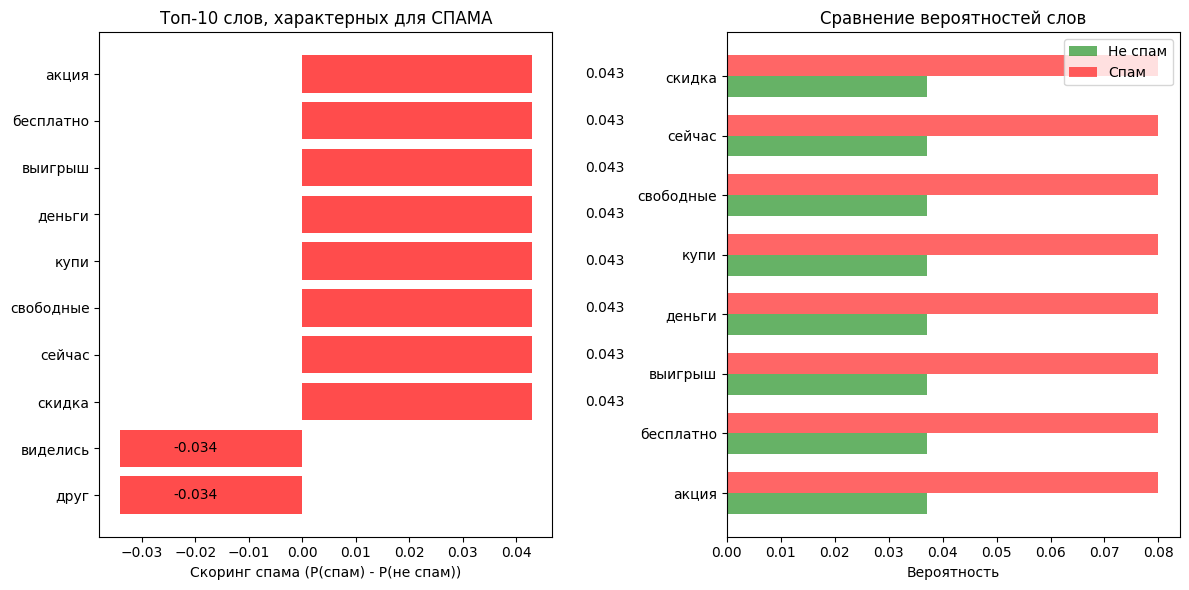

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Данные
texts = [
    'свободные деньги выигрыш бесплатно',
    'привет как дела встреча завтра',
    'купи сейчас скидка акция',
    'привет друг давно не виделись'
]
labels = [1, 0, 1, 0]  # 1=спам, 0=не спам

# Векторизация
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Обучение модели
model = MultinomialNB()
model.fit(X, labels)

# Создаем DataFrame с вероятностями слов
vocab = vectorizer.get_feature_names_out()
log_probs_class0 = model.feature_log_prob_[0]  # Не спам
log_probs_class1 = model.feature_log_prob_[1]  # Спам

# Преобразуем в обычные вероятности
probs_class0 = np.exp(log_probs_class0)
probs_class1 = np.exp(log_probs_class1)

# Разность вероятностей (что более характерно для спама)
spam_score = probs_class1 - probs_class0

# Создаем DataFrame
df_words = pd.DataFrame({
    'Слово': vocab,
    'Вероятность_НеСпам': probs_class0,
    'Вероятность_Спам': probs_class1,
    'Скоринг_Спама': spam_score
}).sort_values('Скоринг_Спама', ascending=False)

print("📊 ТОП-СЛОВА ПО ВАЖНОСТИ ДЛЯ КЛАССИФИКАЦИИ:")
print(df_words.to_string(index=False))

# Визуализация 1: Топ слова для спама
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
top_spam_words = df_words.head(10)
bars1 = plt.barh(top_spam_words['Слово'], top_spam_words['Скоринг_Спама'], 
                color='red', alpha=0.7)
plt.xlabel('Скоринг спама (P(спам) - P(не спам))')
plt.title('Топ-10 слов, характерных для СПАМА')
plt.gca().invert_yaxis()
for bar in bars1:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center')

# Визуализация 2: Сравнение вероятностей
plt.subplot(1, 2, 2)
words_to_show = 8
indices = np.arange(words_to_show)
width = 0.35

# Берем слова с максимальной разницей
top_words = df_words.head(words_to_show)

plt.barh(indices - width/2, top_words['Вероятность_НеСпам'], 
        width, label='Не спам', color='green', alpha=0.6)
plt.barh(indices + width/2, top_words['Вероятность_Спам'], 
        width, label='Спам', color='red', alpha=0.6)

plt.yticks(indices, top_words['Слово'])
plt.xlabel('Вероятность')
plt.title('Сравнение вероятностей слов')
plt.legend()

plt.tight_layout()
plt.show()

### 4.3. Наивный байесовский классификатор - c полной визуализацией на графике 

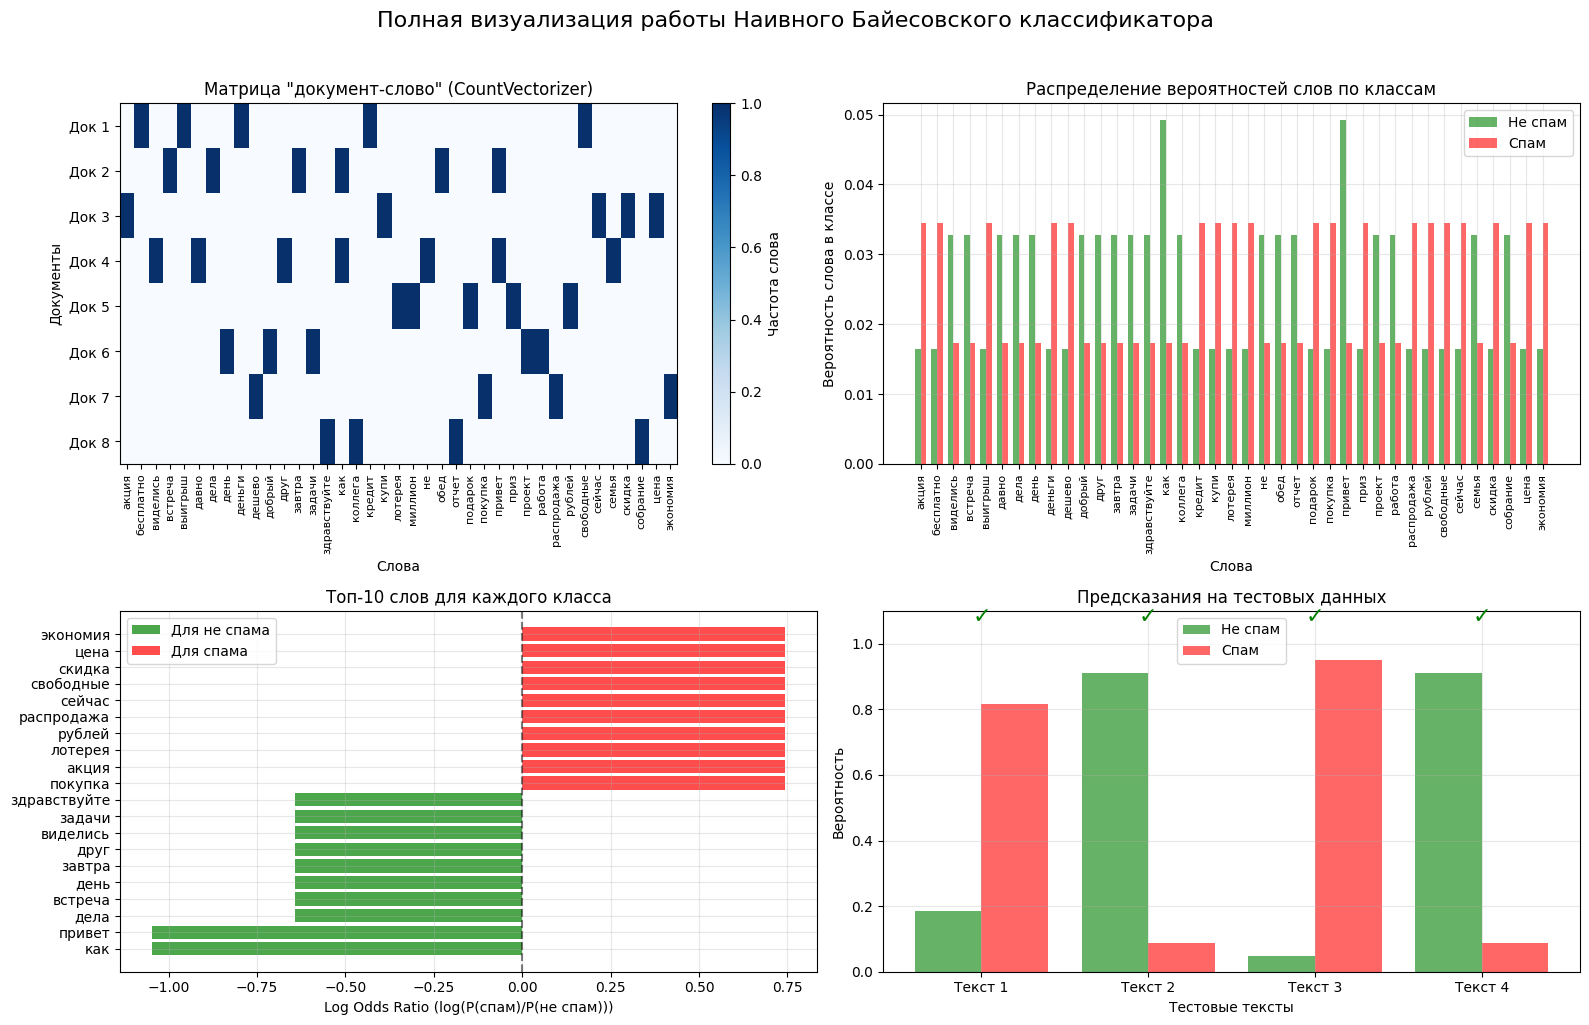

📊 КЛЮЧЕВЫЕ СТАТИСТИКИ МОДЕЛИ:
Количество обучающих текстов: 8
Количество уникальных слов: 39
Априорные вероятности классов:
  P(не спам) = 0.500
  P(спам) = 0.500

Топ-5 слов для определения спама:
  - экономия
  - цена
  - скидка
  - свободные
  - сейчас


In [16]:
# ПОЛНАЯ ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ НАИВНОГО БАЙЕСА
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Увеличим данные для лучшей визуализации
texts_large = [
    'свободные деньги выигрыш бесплатно кредит',
    'привет как дела встреча завтра обед',
    'купи сейчас скидка акция цена',
    'привет друг давно не виделись как семья',
    'миллион рублей подарок лотерея приз',
    'добрый день работа проект задачи',
    'распродажа дешево экономия покупка',
    'здравствуйте коллега отчет собрание'
]
labels_large = [1, 0, 1, 0, 1, 0, 1, 0]  # 1=спам, 0=не спам

# Векторизация
vectorizer = CountVectorizer()
X_large = vectorizer.fit_transform(texts_large)
vocab_large = vectorizer.get_feature_names_out()

# Обучение модели
model_large = MultinomialNB()
model_large.fit(X_large, labels_large)

# Создаем полную визуализацию
fig = plt.figure(figsize=(16, 10))

# 1. Матрица документ-слово
ax1 = plt.subplot(2, 2, 1)
X_dense = X_large.toarray()
im1 = ax1.imshow(X_dense, cmap='Blues', aspect='auto')
ax1.set_title('Матрица "документ-слово" (CountVectorizer)')
ax1.set_xlabel('Слова')
ax1.set_ylabel('Документы')
ax1.set_xticks(range(len(vocab_large)))
ax1.set_xticklabels(vocab_large, rotation=90, fontsize=8)
ax1.set_yticks(range(len(texts_large)))
ax1.set_yticklabels([f"Док {i+1}" for i in range(len(texts_large))])
plt.colorbar(im1, ax=ax1, label='Частота слова')

# 2. Вероятности слов для каждого класса
ax2 = plt.subplot(2, 2, 2)
probs_class0 = np.exp(model_large.feature_log_prob_[0])
probs_class1 = np.exp(model_large.feature_log_prob_[1])

x_pos = np.arange(len(vocab_large))
width = 0.35
ax2.bar(x_pos - width/2, probs_class0, width, label='Не спам', color='green', alpha=0.6)
ax2.bar(x_pos + width/2, probs_class1, width, label='Спам', color='red', alpha=0.6)

ax2.set_xlabel('Слова')
ax2.set_ylabel('Вероятность слова в классе')
ax2.set_title('Распределение вероятностей слов по классам')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(vocab_large, rotation=90, fontsize=8)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Важность слов (log odds ratio)
ax3 = plt.subplot(2, 2, 3)
log_odds = model_large.feature_log_prob_[1] - model_large.feature_log_prob_[0]
sorted_idx = np.argsort(log_odds)

# Топ-10 слов для каждого класса
top_spam_idx = sorted_idx[-10:]  # Наиболее характерны для спама
top_not_spam_idx = sorted_idx[:10]  # Наиболее характерны для не спама

ax3.barh(range(10), log_odds[top_not_spam_idx], color='green', alpha=0.7, label='Для не спама')
ax3.barh(range(10, 20), log_odds[top_spam_idx], color='red', alpha=0.7, label='Для спама')

ax3.set_yticks(list(range(10)) + list(range(10, 20)))
ax3.set_yticklabels(list(vocab_large[top_not_spam_idx]) + list(vocab_large[top_spam_idx]))
ax3.set_xlabel('Log Odds Ratio (log(P(спам)/P(не спам)))')
ax3.set_title('Топ-10 слов для каждого класса')
ax3.legend()
ax3.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)

# 4. Предсказания на тестовых данных
ax4 = plt.subplot(2, 2, 4)
test_texts = [
    "бесплатный выигрыш деньги",
    "привет дела встреча",
    "скидка акция купи сейчас",
    "друг семья привет"
]
true_labels = [1, 0, 1, 0]

test_vec = vectorizer.transform(test_texts)
predictions = model_large.predict(test_vec)
probabilities = model_large.predict_proba(test_vec)

x_pos_test = np.arange(len(test_texts))
ax4.bar(x_pos_test - 0.2, probabilities[:, 0], 0.4, label='Не спам', color='green', alpha=0.6)
ax4.bar(x_pos_test + 0.2, probabilities[:, 1], 0.4, label='Спам', color='red', alpha=0.6)

# Отмечаем правильные/неправильные предсказания
for i, (pred, true) in enumerate(zip(predictions, true_labels)):
    color = 'green' if pred == true else 'red'
    ax4.text(i, 1.05, '✓' if pred == true else '✗', 
            ha='center', va='bottom', fontsize=16, color=color)

ax4.set_xlabel('Тестовые тексты')
ax4.set_ylabel('Вероятность')
ax4.set_title('Предсказания на тестовых данных')
ax4.set_xticks(x_pos_test)
ax4.set_xticklabels([f"Текст {i+1}" for i in range(len(test_texts))])
ax4.set_ylim([0, 1.1])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Полная визуализация работы Наивного Байесовского классификатора', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Вывод ключевых статистик
print("📊 КЛЮЧЕВЫЕ СТАТИСТИКИ МОДЕЛИ:")
print("="*50)
print(f"Количество обучающих текстов: {len(texts_large)}")
print(f"Количество уникальных слов: {len(vocab_large)}")
print(f"Априорные вероятности классов:")
print(f"  P(не спам) = {np.exp(model_large.class_log_prior_[0]):.3f}")
print(f"  P(спам) = {np.exp(model_large.class_log_prior_[1]):.3f}")
print("\nТоп-5 слов для определения спама:")
top_spam_words = vocab_large[np.argsort(log_odds)[-5:]]
for word in reversed(top_spam_words):
    print(f"  - {word}")

### 5. Метод ближайших соседей (kNN)

Размер данных: (100, 2)
Баланс классов: [50 50]


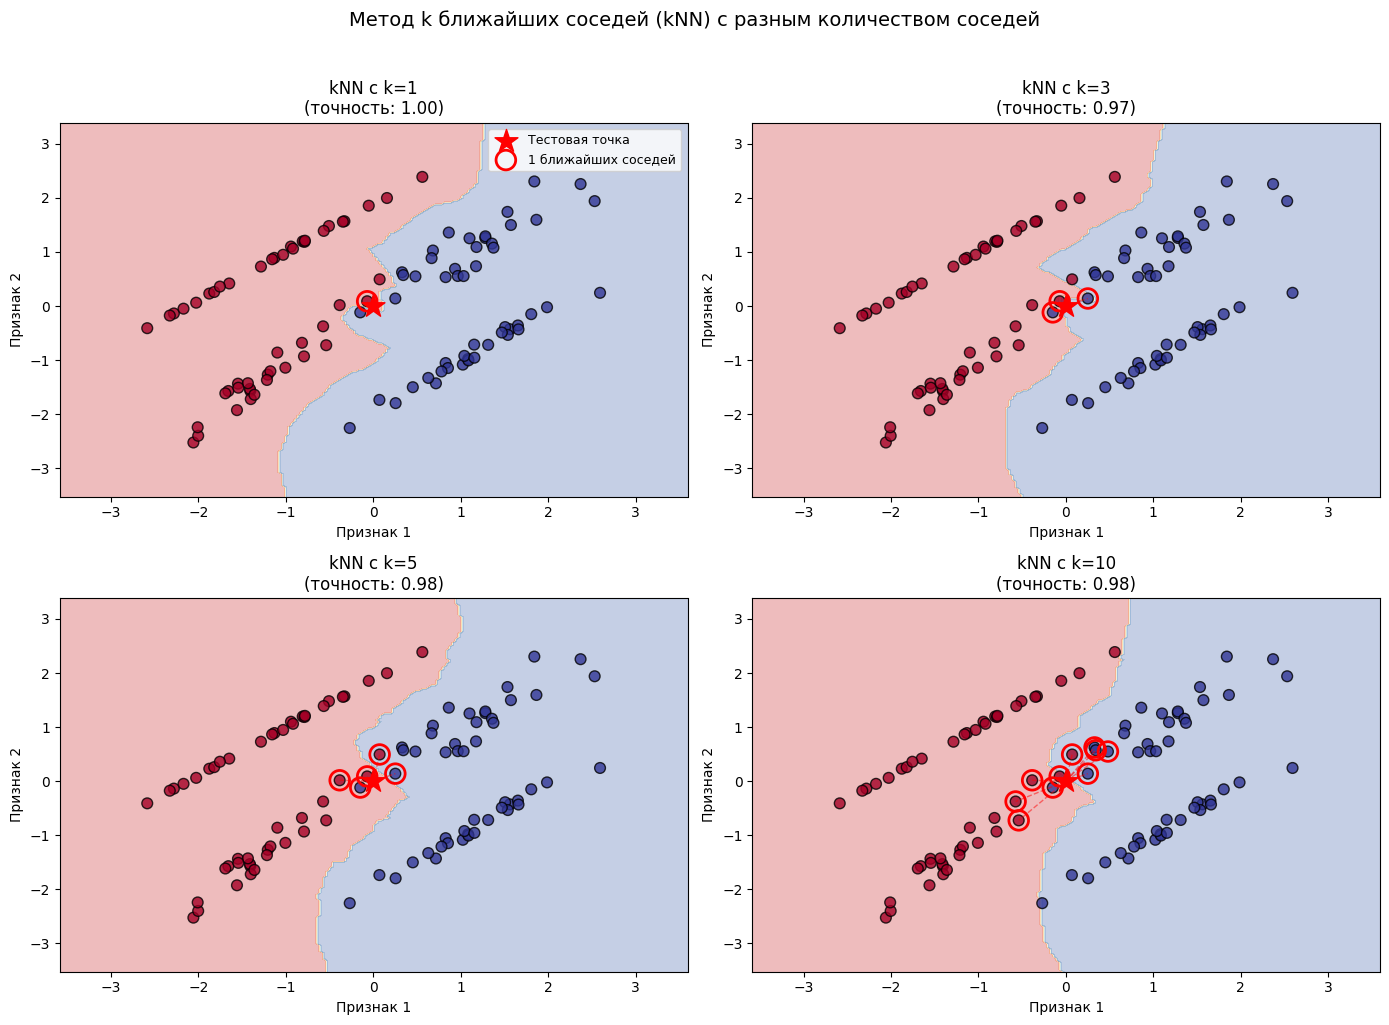

In [17]:
# kNN С РАЗНЫМ КОЛИЧЕСТВОМ СОСЕДЕЙ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

# СОЗДАЕМ ДАННЫЕ с правильными параметрами
X, y = make_classification(
    n_samples=100, 
    n_features=2,
    n_informative=2,  # Явно указываем информативные признаки
    n_redundant=0,    # Явно указываем избыточные признаки
    n_repeated=0,     # Явно указываем повторяющиеся признаки
    random_state=42
)

print(f"Размер данных: {X.shape}")
print(f"Баланс классов: {np.bincount(y)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, k in enumerate([1, 3, 5, 10]):
    ax = axes[idx]
    
    # Обучаем модель kNN
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    
    # Создаем сетку для границы решений
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Предсказания для сетки
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Отображаем границу решений
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # Отображаем обучающие точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                        edgecolors='k', s=60, alpha=0.8)
    
    # Показываем ближайших соседей для тестовой точки
    test_point = [[0, 0]]
    distances, indices = model.kneighbors(test_point, n_neighbors=k)
    
    # Тестовая точка (красная звезда)
    ax.scatter(test_point[0][0], test_point[0][1], c='red', 
              s=300, marker='*', label='Тестовая точка', zorder=5)
    
    # Ближайшие соседи (обведены красным)
    ax.scatter(X[indices[0], 0], X[indices[0], 1], 
              facecolors='none', edgecolors='red', s=200, 
              linewidths=2, label=f'{k} ближайших соседей', zorder=4)
    
    # Линии к соседям
    for neighbor_idx in indices[0]:
        ax.plot([test_point[0][0], X[neighbor_idx, 0]], 
               [test_point[0][1], X[neighbor_idx, 1]], 
               'r--', alpha=0.5, linewidth=1)
    
    ax.set_title(f'kNN с k={k}\n(точность: {model.score(X, y):.2f})')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Метод k ближайших соседей (kNN) с разным количеством соседей', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Метод ближайших соседей (kNN) - Альтернатива: создаем данные вручную для наглядности

Созданные данные:
Класс 0: 25 точек вокруг (1, 1)
Класс 1: 25 точек вокруг (3, 3)


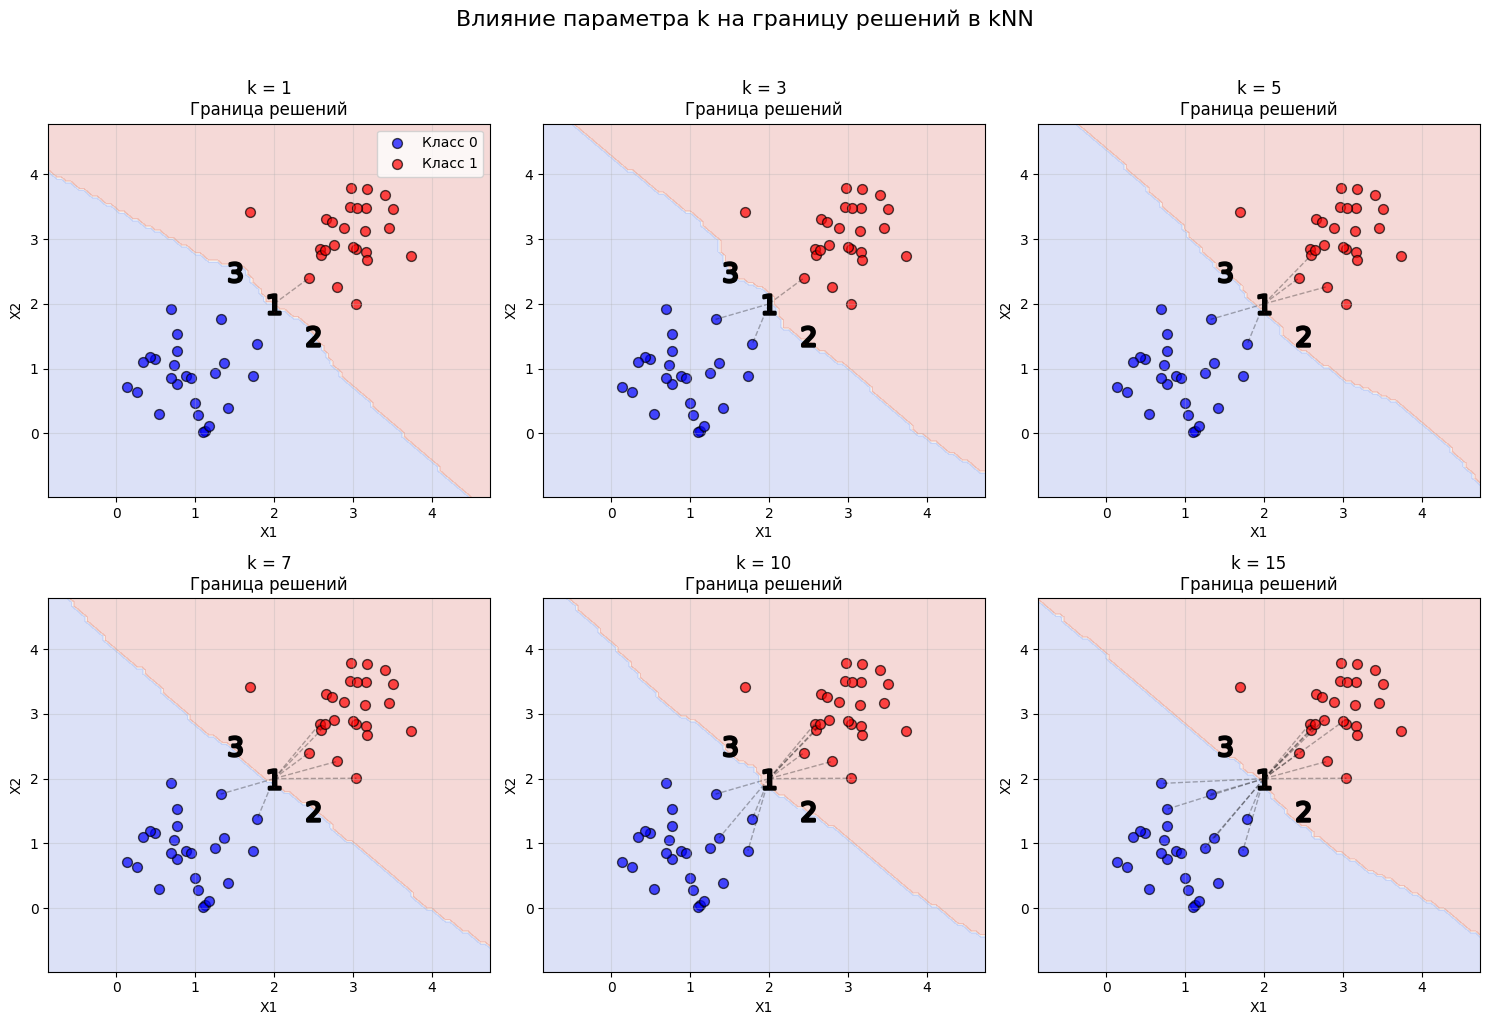


📏 РАССТОЯНИЯ МЕЖДУ ТОЧКАМИ:
----------------------------------------
Тестовая точка: [2, 2]

Ближайшие 5 соседей:
1. Точка [2.44683251 2.40189669] (класс 1)
   Расстояние: 0.601
   Евклидово расстояние: 0.601

2. Точка [1.78960641 1.38371736] (класс 0)
   Расстояние: 0.651
   Евклидово расстояние: 0.651

3. Точка [1.32384427 1.76151493] (класс 0)
   Расстояние: 0.717
   Евклидово расстояние: 0.717

4. Точка [2.80394592 2.26824253] (класс 1)
   Расстояние: 0.848
   Евклидово расстояние: 0.848

5. Точка [2.5957532  2.74912148] (класс 1)
   Расстояние: 0.957
   Евклидово расстояние: 0.957



In [18]:
# kNN НА ПРОСТЫХ РУЧНЫХ ДАННЫХ
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

# Создаем простые данные вручную
np.random.seed(42)

# Класс 0 (синие)
X0 = np.random.randn(25, 2) * 0.5 + [1, 1]
# Класс 1 (красные)
X1 = np.random.randn(25, 2) * 0.5 + [3, 3]

X = np.vstack([X0, X1])
y = np.array([0]*25 + [1]*25)

print("Созданные данные:")
print(f"Класс 0: {len(X0)} точек вокруг (1, 1)")
print(f"Класс 1: {len(X1)} точек вокруг (3, 3)")

# Визуализация разных значений k
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

k_values = [1, 3, 5, 7, 10, 15]

for idx, k in enumerate(k_values):
    ax = axes[idx]
    
    # Обучаем модель
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    
    # Создаем сетку
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Предсказания
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Граница решений
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    
    # Данные
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, 
              alpha=0.7, label='Класс 0', edgecolors='k')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red', s=50, 
              alpha=0.7, label='Класс 1', edgecolors='k')
    
    # Несколько тестовых точек
    test_points = [[2, 2], [2.5, 1.5], [1.5, 2.5]]
    
    for i, test_point in enumerate(test_points):
        # Предсказание для тестовой точки
        pred = model.predict([test_point])[0]
        
        # Находим соседей
        distances, indices = model.kneighbors([test_point], n_neighbors=k)
        
        # Рисуем тестовую точку
        color = 'red' if pred == 1 else 'blue'
        ax.scatter(test_point[0], test_point[1], c=color, 
                  s=200, marker=f'${i+1}$', edgecolors='k', linewidths=2, zorder=5)
        
        # Рисуем линии к соседям (только для первой точки для наглядности)
        if i == 0:
            for neighbor_idx in indices[0]:
                ax.plot([test_point[0], X[neighbor_idx, 0]], 
                       [test_point[1], X[neighbor_idx, 1]], 
                       'k--', alpha=0.3, linewidth=1)
    
    ax.set_title(f'k = {k}\nГраница решений')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend(loc='upper right')

plt.suptitle('Влияние параметра k на границу решений в kNN', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Демонстрация работы расстояний
print("\n📏 РАССТОЯНИЯ МЕЖДУ ТОЧКАМИ:")
print("-" * 40)

test_point = [[2, 2]]
model_all = KNeighborsClassifier(n_neighbors=len(X))
model_all.fit(X, y)

distances, indices = model_all.kneighbors(test_point)

print(f"Тестовая точка: {test_point[0]}")
print("\nБлижайшие 5 соседей:")
for i in range(5):
    neighbor_idx = indices[0][i]
    neighbor_point = X[neighbor_idx]
    distance = distances[0][i]
    neighbor_class = y[neighbor_idx]
    
    print(f"{i+1}. Точка {neighbor_point} (класс {neighbor_class})")
    print(f"   Расстояние: {distance:.3f}")
    print(f"   Евклидово расстояние: {np.linalg.norm(test_point[0] - neighbor_point):.3f}")
    print()

# спешил не успел перекинуть и раз фосовать

Взял из модуля валидации 

In [19]:
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'model_selection' is not defined

In [ ]:
print('Train shape: {}'.format(X_train.shape))
print('Valid shape: {}'.format(X_valid.shape))
  
## Train shape: (2620, 9)
## Valid shape: (656, 9)

In [ ]:
#Создаём модель
model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел  
)
#Обучаем модель на тренировочной выборке
model.fit(X_train, y_train)
#Делаем предсказание для каждой из выборок
y_train_pred = model.predict(X_train)
y_valid_pred = model.predict(X_valid)
#Выводим значения метрик
print('Train hold-out accuracy: {:.2f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Valid hold-out accuracy: {:.2f}'.format(metrics.accuracy_score(y_valid, y_valid_pred))) 
 
# Train hold-out accuracy: 0.82
# Valid hold-out accuracy: 0.77

In [ ]:
#разбиваем исходную выборку на тренировочную и валидационную в соотношении 80/20
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
#разбиваем валидационную выборку на валидационную и тестовую в соотношении 50/50
X_valid, X_test, y_valid, y_test = model_selection.train_test_split(X_valid, y_valid, test_size=0.5, random_state=42)

In [ ]:
print('Train shape: {}'.format(X_train.shape))
print('Valid shape: {}'.format(X_valid.shape))
print('Test shape: {}'.format(X_test.shape))

## Train shape: (2620, 9)
## Valid shape: (328, 9)
## Test shape: (328, 9)

In [ ]:
#Создаём модель
model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел  
)
 
#Создаём объект кросс-валидатора KFold
kf = model_selection.KFold(n_splits=5)
#Создаём список для хранения тренировочных и валидационных метрик
train_metrics = []
val_metrics = []
#Организуем цикл для кросс-валидации (используем весь набор данных)
#train_index — индексы тренировочной выборки
#valid_index — индексы валидационной выборки
for train_index, valid_index in kf.split(X, y): 
    #Создаём тренировочную и валидационную выборку, обращаясь по текущим индексам
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    X_valid, y_valid = X.iloc[valid_index], y.iloc[valid_index]
    #Обучаем дерево решений на тренировочной выборке
    model.fit(X_train, y_train)
    #Делаем предсказание для каждой из выборок
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    #Рассчитываем метрику и заносим её в список
    train_metrics.append(metrics.accuracy_score(y_train, y_train_pred))
    val_metrics.append(metrics.accuracy_score(y_valid, y_valid_pred))

In [ ]:
#Создаём модель
model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел  
)
 
#Создаём объект кросс-валидатора KFold
kf = model_selection.KFold(n_splits=5)
 
#Считаем метрики на кросс-валидации k-fold
cv_metrics = model_selection.cross_validate(
    estimator=model, #модель
    X=X, #матрица наблюдений X
    y=y, #вектор ответов y
    cv=kf, #кросс-валидатор
    scoring='accuracy', #метрика
    return_train_score=True #подсчёт метрики на тренировочных фолдах
)
display(cv_metrics)

In [ ]:
print('Train k-fold mean accuracy: {:.2f}'.format(np.mean(cv_metrics['train_score'])))
print('Valid k-fold mean accuracy: {:.2f}'.format(np.mean(cv_metrics['test_score'])))
 
## Train k-fold mean accuracy: 0.81
## Valid k-fold mean accuracy: 0.74

In [ ]:
# Для hold-out
from sklearn.model_selection import train_test_split

# Для k-fold
from sklearn.model_selection import KFold, cross_validate

# Для leave-one-out
from sklearn.model_selection import LeaveOneOut, cross_validate

In [ ]:
from sklearn.model_selection import (
    train_test_split,      # для hold-out
    KFold,                 # для k-fold
    LeaveOneOut,           # для leave-one-out
    cross_validate         # для k-fold и leave-one-out
)

In [ ]:
# Hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# K-fold (5 фолдов)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(model, X, y, cv=kf, scoring='accuracy')

# Leave-one-out
loo = LeaveOneOut()
cv_results = cross_validate(model, X, y, cv=loo, scoring='accuracy')

In [ ]:
from sklearn import datasets
X, y = datasets.make_classification(
    n_samples=200, #количество объектов
    n_features=2, #количество признаков
    n_informative=2, #количество информативных признаков
    n_redundant=0, #количество неинформативных признаков
    n_classes=2, #количество классов
    weights=[1, 0.2], #пропорции классов
    random_state=40 #генератор случайных чисел
)
X_train, X_valid, y_train, y_valid= model_selection.train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
log_reg = linear_model.LogisticRegression()
log_reg.fit(X_train, y_train)
y_valid_pred = log_reg.predict(X_valid)
print(metrics.classification_report(y_valid, y_valid_pred))

def plot_probabilities_2d(X, y, model):
    #Генерируем координатную сетку из всех возможных значений для признаков
    #Результат работы функции — два массива xx1 и xx2, которые образуют координатную сетку
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    #Вытягиваем каждый из массивов в вектор-столбец — reshape(-1, 1)
    #Объединяем два столбца в таблицу с помощью hstack
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    #Предсказываем вероятность для всех точек на координатной сетке
    #Нам нужна только вероятность класса 1
    probs = model.predict_proba(X_net)[:, 1]
    #Переводим столбец из вероятностей в размер координатной сетки
    probs = probs.reshape(xx1.shape)
    #Создаём фигуру и координатную плоскость
    fig, ax = plt.subplots(figsize = (10, 5))
    #Рисуем тепловую карту вероятностей
    contour = ax.contourf(xx1, xx2, probs, 100, cmap='bwr')
    #Рисуем разделяющую плоскость — линию, где вероятность равна 0.5
    bound = ax.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    #Добавляем цветовую панель 
    colorbar = fig.colorbar(contour)
    #Накладываем поверх тепловой карты диаграмму рассеяния
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette='seismic', ax=ax)
    #Даём графику название
    ax.set_title('Scatter Plot with Decision Boundary');
    #Смещаем легенду в верхний левый угол вне графика
    ax.legend(bbox_to_anchor=(-0.05, 1))

NameError: name 'model_selection' is not defined

In [ ]:
#Создаём модель
model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    class_weight='balanced', 
    random_state=42, #генератор случайных чисел 
)
 
#Создаём объект кросс-валидатора k-fold со стратификацией
skf = model_selection.StratifiedKFold(n_splits=5)
 
#Вычисляем координаты для построения кривой обучения
train_sizes, train_scores, valid_scores = model_selection.learning_curve(
    estimator = model, #модель
    X = X, #матрица наблюдений X
    y = y, #вектор ответов y
    cv = skf, #кросс-валидатор
    scoring = 'f1' #метрика
)
print('Train sizes: \n', train_sizes)
print('Train scores: \n', train_scores)
print('Valid scores: \n', valid_scores)

NameError: name 'tree' is not defined

In [20]:
def plot_learning_curve(model, X, y, cv, scoring="f1", ax=None, title=""):
    # Вычисляем координаты для построения кривой обучения
    train_sizes, train_scores, valid_scores = model_selection.learning_curve(
        estimator=model,  # модель
        X=X,  # матрица наблюдений X
        y=y,  # вектор ответов y
        cv=cv,  # кросс-валидатор
        scoring=scoring,  # метрика
    )
    # Вычисляем среднее значение по фолдам для каждого набора данных
    train_scores_mean = np.mean(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)
    # Если координатной плоскости не было передано, создаём новую
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))  # фигура + координатная плоскость
    # Строим кривую обучения по метрикам на тренировочных фолдах
    ax.plot(train_sizes, train_scores_mean, label="Train")
    # Строим кривую обучения по метрикам на валидационных фолдах
    ax.plot(train_sizes, valid_scores_mean, label="Valid")
    # Даём название графику и подписи осям
    ax.set_title("Learning curve: {}".format(title))
    ax.set_xlabel("Train data size")
    ax.set_ylabel("Score")
    # Устанавливаем отметки по оси абсцисс
    ax.xaxis.set_ticks(train_sizes)
    # Устанавливаем диапазон оси ординат
    ax.set_ylim(0, 1)
    # Отображаем легенду
    ax.legend()

In [ ]:
from sklearn

In [21]:
#Создаём список из моделей
models = [
    linear_model.LogisticRegression(
        max_iter=1000, #количество итераций на сходимость
        random_state=42, #генератор случайных чисел
        class_weight='balanced' #веса классов
    ),
    tree.DecisionTreeClassifier(
        criterion='entropy', #критерий информативности
        max_depth=7, #максимальная глубина
        min_samples_leaf=5, #минимальное число объектов в листе
        random_state=42, #генератор случайных чисел 
        class_weight='balanced' #веса классов
    ),
    tree.DecisionTreeClassifier(
        criterion='entropy', #критерий информативности
        random_state=42, #генератор случайных чисел 
        class_weight='balanced' #веса классов
    ),
]

NameError: name 'linear_model' is not defined